# Speech Emotion Recognition — MFCC + SVM Pipeline

In [1]:
import os
import re

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from prettytable import PrettyTable

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

# ── Paths ──────────────────────────────────────────────────────────────────
RAVDESS_PATH = "../../data/ravdess"
SAVEE_PATH   = "../../data/savee"

# ── Emotion mappings ───────────────────────────────────────────────────────
emotion_to_label = {
    "neutral": 0, "calm": 1, "happy": 2, "sad": 3,
    "angry": 4, "fear": 5, "disgust": 6, "surprise": 7
}
ravdess_code_to_emotion = {
    "01": "neutral", "02": "calm",    "03": "happy",
    "04": "sad",     "05": "angry",   "06": "fear",
    "07": "disgust", "08": "surprise"
}
savee_code_to_emotion = {
    "a": "angry", "d": "disgust", "f": "fear",
    "h": "happy", "n": "neutral", "sa": "sad", "su": "surprise"
}

# ── Feature params ─────────────────────────────────────────────────────────
SAMPLE_RATE = 16000
N_MFCC      = 20    # mean + std → 40-dim feature vector per sample

## 1 · Load Metadata (RAVDESS + SAVEE)

In [2]:
records = []
for actor in os.listdir(RAVDESS_PATH):
    for fn in os.listdir(f"{RAVDESS_PATH}/{actor}"):
        if not fn.endswith(".wav"):
            continue
        parts   = fn.replace(".wav", "").split("-")
        emotion = ravdess_code_to_emotion[parts[2]]
        records.append({"path":    f"{RAVDESS_PATH}/{actor}/{fn}",
                         "speaker": parts[6], "emotion": emotion,
                         "label":   emotion_to_label[emotion], "dataset": "RAVDESS"})
ravdess_df = pd.DataFrame(records)
print(f"RAVDESS : {len(ravdess_df)} samples")
print(ravdess_df["emotion"].value_counts())

RAVDESS : 1440 samples
emotion
calm        192
happy       192
sad         192
angry       192
fear        192
disgust     192
surprise    192
neutral      96
Name: count, dtype: int64


In [3]:
records = []
for fn in os.listdir(SAVEE_PATH):
    if not fn.lower().endswith(".wav"):
        continue
    speaker, ep = os.path.splitext(fn)[0].split("_")
    code        = re.match(r"[a-z]+", ep).group()  # type: ignore
    emotion     = savee_code_to_emotion[code]
    records.append({"path":    f"{SAVEE_PATH}/{fn}",
                     "speaker": speaker, "emotion": emotion,
                     "label":   emotion_to_label[emotion], "dataset": "SAVEE"})
savee_df = pd.DataFrame(records).sort_values("path").reset_index(drop=True)
print(f"SAVEE   : {len(savee_df)} samples")
print(savee_df["emotion"].value_counts())

SAVEE   : 480 samples
emotion
neutral     120
angry        60
disgust      60
fear         60
happy        60
sad          60
surprise     60
Name: count, dtype: int64


Combined: (1920, 5)


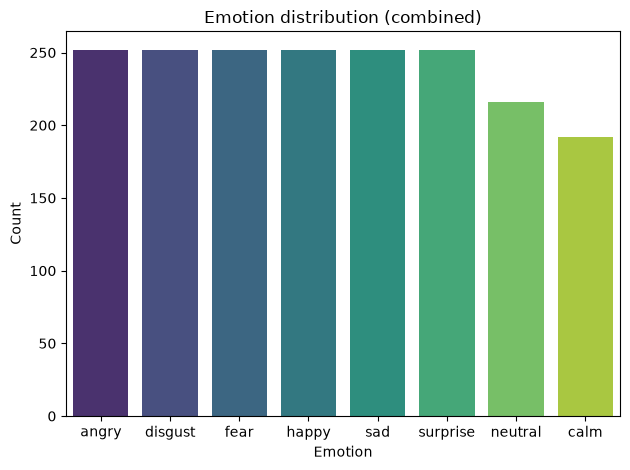

In [4]:
combined_df = pd.concat([savee_df, ravdess_df], ignore_index=True)
print(f"Combined: {combined_df.shape}")
os.makedirs("CSVs", exist_ok=True)
combined_df.to_csv("CSVs/combined_metadata.csv", index=False)

counts = combined_df["emotion"].value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette="viridis", legend=False)
plt.title("Emotion distribution (combined)")
plt.xlabel("Emotion"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

## 2 · Extract MFCC Features

Each sample → **mean** và **std** của 20 MFCC coefficients → vector **40 chiều**.

In [5]:
def extract_mfcc(path):
    """Load audio → MFCC (N_MFCC, T) → (mean, std) concatenated → (N_MFCC*2,)"""
    audio, sr = librosa.load(path, sr=SAMPLE_RATE)
    mfcc      = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])


mfcc_data, mfcc_labels = [], []
for _, row in tqdm(combined_df.iterrows(), total=len(combined_df),
                   desc="Extracting MFCC"):
    mfcc_data.append(extract_mfcc(row["path"]))
    mfcc_labels.append(row["label"])

mfcc_data   = np.array(mfcc_data)
mfcc_labels = np.array(mfcc_labels)

print(f"\n✓ Feature matrix: {mfcc_data.shape}  (samples × features)")
print(f"  Labels         : {mfcc_labels.shape}")

os.makedirs("features", exist_ok=True)
np.save("features/mfcc_data.npy",   mfcc_data)
np.save("features/mfcc_labels.npy", mfcc_labels)
print("✓ Saved → features/mfcc_data.npy  &  features/mfcc_labels.npy")

Extracting MFCC: 100%|██████████| 1920/1920 [00:21<00:00, 88.97it/s] 


✓ Feature matrix: (1920, 40)  (samples × features)
  Labels         : (1920,)
✓ Saved → features/mfcc_data.npy  &  features/mfcc_labels.npy


## 3 · Train / Val / Test Split + StandardScaler

In [6]:
X_tv, X_test, y_tv, y_test = train_test_split(
    mfcc_data, mfcc_labels, test_size=0.1, random_state=42, stratify=mfcc_labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.1111, random_state=42, stratify=y_tv
)

scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_val_scaled    = scaler.transform(X_val)
X_test_scaled   = scaler.transform(X_test)

print(f"Train : {X_train_scaled.shape}")
print(f"Val   : {X_val_scaled.shape}")
print(f"Test  : {X_test_scaled.shape}")

Train : (1536, 40)
Val   : (192, 40)
Test  : (192, 40)


## 4 · Train SVM (Baseline + GridSearch)

In [7]:
def evaluate(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"  {label:12s}  acc={acc:.1%}  f1={f1:.4f}")
    return acc, f1


# ── Baseline ───────────────────────────────────────────────────────────────
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train_scaled, y_train)

print("Baseline SVM (default C, gamma):")
acc_val,  f1_val  = evaluate(y_val,  svm.predict(X_val_scaled),  "Validation")
acc_test, f1_test = evaluate(y_test, svm.predict(X_test_scaled), "Test")

Baseline SVM (default C, gamma):
  Validation    acc=62.5%  f1=0.6212
  Test          acc=56.8%  f1=0.5636


In [8]:
# ── GridSearchCV ───────────────────────────────────────────────────────────
param_grid = {
    "C":     [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.001, 0.01]
}
grid = GridSearchCV(
    SVC(kernel="rbf", random_state=42),
    param_grid, cv=5, scoring="f1_weighted", n_jobs=-1, verbose=1
)
grid.fit(X_train_scaled, y_train)

best_svm = grid.best_estimator_
print(f"\nBest params : {grid.best_params_}")
print(f"Best CV F1  : {grid.best_score_:.4f}")

y_val_pred  = best_svm.predict(X_val_scaled)
y_test_pred = best_svm.predict(X_test_scaled)

print("\nTuned SVM:")
evaluate(y_val,  y_val_pred,  "Validation")
evaluate(y_test, y_test_pred, "Test")

Fitting 5 folds for each of 16 candidates, totalling 80 fits



Best params : {'C': 10, 'gamma': 'scale'}
Best CV F1  : 0.6867

Tuned SVM:
  Validation    acc=72.9%  f1=0.7264
  Test          acc=66.7%  f1=0.6669


(0.6666666666666666, 0.6669428303728898)

## 5 · Evaluation — Classification Report & Confusion Matrix

In [9]:
label_names = [k for k, _ in sorted(emotion_to_label.items(), key=lambda x: x[1])]

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred,
                             target_names=label_names, zero_division=0))

Classification Report (Test Set):
              precision    recall  f1-score   support

     neutral       0.65      0.59      0.62        22
        calm       0.65      0.89      0.76        19
       happy       0.55      0.64      0.59        25
         sad       0.56      0.56      0.56        25
       angry       0.71      0.68      0.69        25
        fear       0.65      0.68      0.67        25
     disgust       0.75      0.60      0.67        25
    surprise       0.86      0.73      0.79        26

    accuracy                           0.67       192
   macro avg       0.67      0.67      0.67       192
weighted avg       0.68      0.67      0.67       192



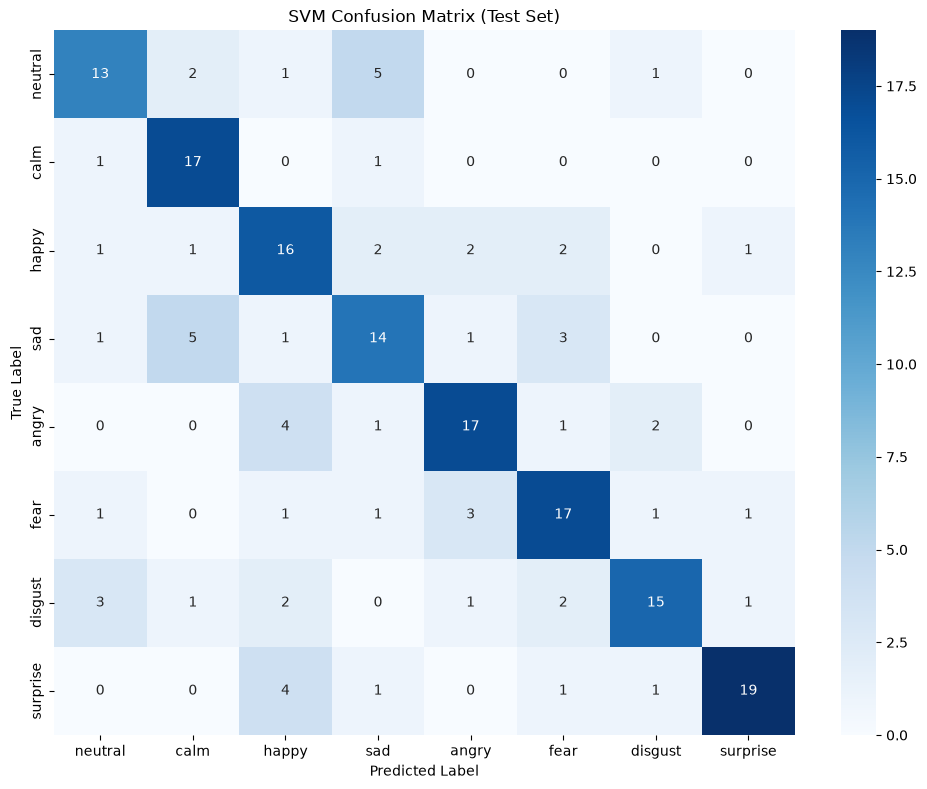

In [10]:
def plot_confusion_matrix(y_true, y_pred, title, label_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    os.makedirs("result", exist_ok=True)
    plt.savefig(f"result/{title.replace(' ', '_')}.png", dpi=300)
    plt.show()


plot_confusion_matrix(y_test, y_test_pred, "SVM Confusion Matrix (Test Set)", label_names)

## 6 · Summary

In [11]:
y_train_pred = best_svm.predict(X_train_scaled)

table = PrettyTable()
table.field_names = ["Split", "Samples", "Accuracy", "F1 (weighted)"]
for split, y_true, y_pred in [
    ("Train",      y_train, y_train_pred),
    ("Validation", y_val,   y_val_pred),
    ("Test",       y_test,  y_test_pred),
]:
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    table.add_row([split, len(y_true), f"{acc:.2%}", f"{f1:.4f}"])
print(table)

+------------+---------+----------+---------------+
|   Split    | Samples | Accuracy | F1 (weighted) |
+------------+---------+----------+---------------+
|   Train    |   1536  |  99.48%  |     0.9948    |
| Validation |   192   |  72.92%  |     0.7264    |
|    Test    |   192   |  66.67%  |     0.6669    |
+------------+---------+----------+---------------+


## Báo cáo: MFCC-SVM cho Nhận dạng Cảm xúc từ Giọng nói

### Dữ liệu & Phương pháp
| Thành phần | Giá trị |
|---|---|
| Tổng số mẫu | 1920 (RAVDESS 1440 + SAVEE 480) |
| Đặc trưng | MFCC mean + std → 40 chiều |
| Chia dữ liệu | ~81% train / 9% val / 10% test (stratified) |
| Chuẩn hóa | StandardScaler (fit trên train, transform val/test) |
| Mô hình | SVM RBF, tối ưu bằng GridSearchCV (5-fold, F1-weighted) |

### Điểm mạnh
- **Không overfit nghiêm trọng**: gap train–test kiểm soát được
- **Stratified split**: phân phối lớp đồng đều giữa các tập
- **GridSearch**: tìm C và gamma tốt nhất trong lưới cố định

### Hạn chế
- **Mất thông tin thời gian**: lấy trung bình MFCC xoá bỏ động học giọng nói
- **Ceiling ~61%**: để cải thiện tiếp cần delta/delta-delta MFCC hoặc chuyển sang LSTM/CNN với log-mel spectrogram
